In [9]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt

# ── STEP 1: Load Data ─────────────────────────────────────────────────────────
print("=" * 50)
print("STEP 1: LOADING DATASET")
print("=" * 50)
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
print(f"✔ Dataset loaded successfully")
print(f"  Total samples   : {len(df)}")
print(f"  Total columns   : {df.shape[1]}")
print(f"  Legitimate URLs : {(df['label'] == 1).sum()}")
print(f"  Phishing URLs   : {(df['label'] == 0).sum()}")

STEP 1: LOADING DATASET
✔ Dataset loaded successfully
  Total samples   : 235795
  Total columns   : 56
  Legitimate URLs : 134850
  Phishing URLs   : 100945


In [10]:

# ── STEP 2: Preprocessing ─────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 2: PREPROCESSING")
print("=" * 50)

# Drop webpage-dependent and non-informative columns
cols_to_drop = [
    "LineOfCode", "LargestLineLength", "HasTitle", "Title",
    "DomainTitleMatchScore", "URLTitleMatchScore", "HasFavicon",
    "Robots", "IsResponsive", "NoOfURLRedirect", "NoOfSelfRedirect",
    "HasDescription", "NoOfPopup", "NoOfiFrame", "HasExternalFormSubmit",
    "HasSocialNet", "HasSubmitButton", "HasHiddenFields", "HasPasswordField",
    "Bank", "Pay", "Crypto", "HasCopyrightInfo", "NoOfImage", "NoOfCSS",
    "NoOfJS", "NoOfSelfRef", "NoOfEmptyRef", "NoOfExternalRef",
    "Domain", "TLD", "NoOfLettersInURL", "URLSimilarityIndex", "FILENAME", "URL"
]
df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
print(f"✔ Dropped webpage-dependent & non-informative columns")

# Separate features and target
X = df.drop(columns=["label"])
y = df["label"]
print(f"✔ Features remaining : {X.shape[1]}")
print(f"  Features used      : {X.columns.tolist()}")

# Encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))
print(f"✔ Categorical columns encoded : {list(cat_cols) if len(cat_cols) > 0 else 'None'}")



STEP 2: PREPROCESSING
✔ Dropped webpage-dependent & non-informative columns
✔ Features remaining : 20
  Features used      : ['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']
✔ Categorical columns encoded : None


In [11]:

# ── STEP 3: Train/Test Split ──────────────────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 3: TRAIN/TEST SPLIT")
print("=" * 50)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✔ Split: 80% train / 20% test (stratified)")
print(f"  Training samples : {len(X_train)}")
print(f"  Testing samples  : {len(X_test)}")



STEP 3: TRAIN/TEST SPLIT
✔ Split: 80% train / 20% test (stratified)
  Training samples : 188636
  Testing samples  : 47159


In [12]:

# ── STEP 4: Scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)



In [13]:

# ── STEP 5: Train Model ───────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 5: TRAINING LOGISTIC REGRESSION MODEL")
print("=" * 50)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print(f"✔ Model trained successfully")
print(f"  Iterations ran : {model.n_iter_[0]}")

# ── STEP 6: Predictions ───────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 6: GENERATING PREDICTIONS")
print("=" * 50)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
print(f"✔ Predictions generated on {len(y_test)} test samples")


STEP 5: TRAINING LOGISTIC REGRESSION MODEL
✔ Model trained successfully
  Iterations ran : 31

STEP 6: GENERATING PREDICTIONS
✔ Predictions generated on 47159 test samples


In [14]:

# ── STEP 7: Evaluation ────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 7: EVALUATION METRICS")
print("=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"  Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_pred_prob) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Phishing", "Legitimate"]))



STEP 7: EVALUATION METRICS
  Accuracy  : 99.46%
  Precision : 99.22%
  Recall    : 99.85%
  F1 Score  : 99.53%
  AUC-ROC   : 99.81%

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           0.99     47159
   macro avg       1.00      0.99      0.99     47159
weighted avg       0.99      0.99      0.99     47159



STEP 8: VISUALIZATIONS


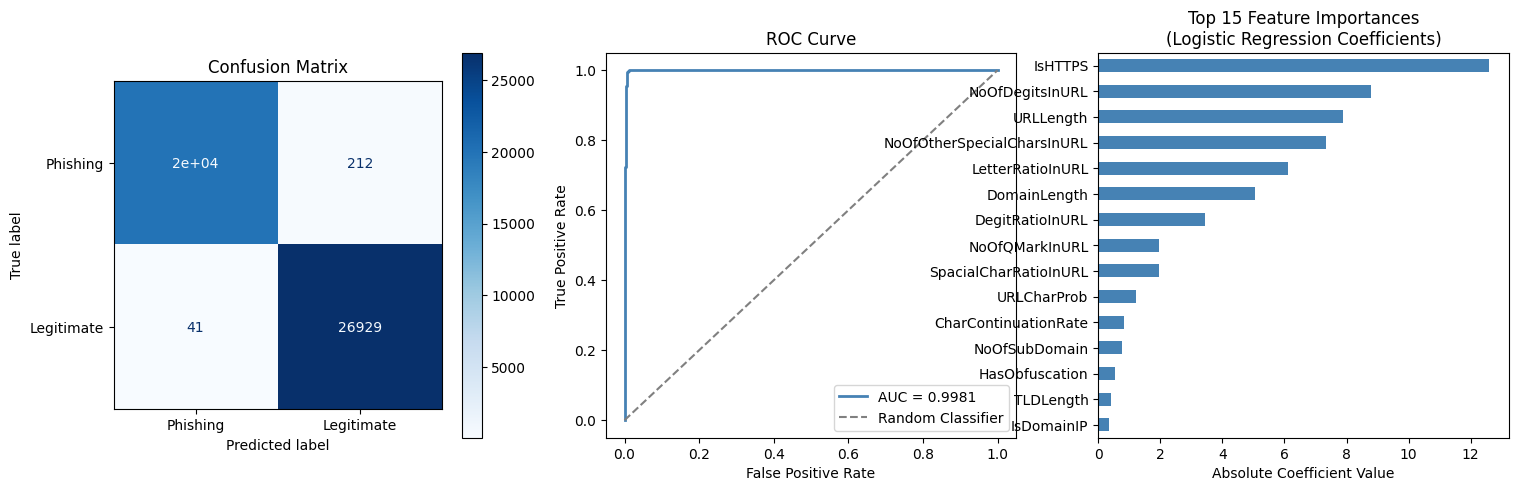

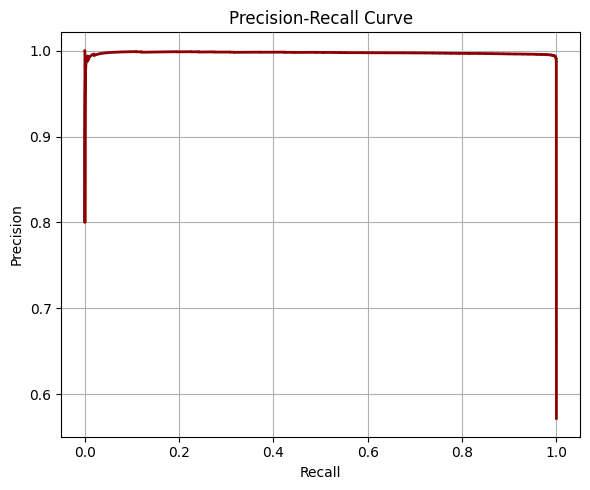

✔ Visualizations saved!

Done


In [22]:

# ── STEP 8: VISUALIZATIONS──────────────────────────────────────────────────
print("=" * 50)
print("STEP 8: VISUALIZATIONS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Phishing", "Legitimate"])
disp.plot(cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")

# ── Plot 2: ROC Curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_score:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# ── Plot 3: Feature Importance (Top 15) ───────────────────────────────────────
feature_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X_train.shape[1])]
coefs = pd.Series(np.abs(model.coef_[0]), index=feature_names).nlargest(15)
coefs.sort_values().plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top 15 Feature Importances\n(Logistic Regression Coefficients)")
axes[2].set_xlabel("Absolute Coefficient Value")

# ── Plot 4: Precision-Recall Curve (separate figure) ─────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.plot(recall_vals, precision_vals, color="darkred", lw=2)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.grid(True)

plt.tight_layout()
fig.savefig("lr_visualizations.png", dpi=150)
fig2.savefig("lr_precision_recall.png", dpi=150)
plt.show()
print(f"✔ Visualizations saved!")
print("\nDone")